In [1]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Load data
# ============================================================

file_path = r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\Bavaria.xlsx"

df = pd.read_excel(file_path)

# ============================================================
# 2. Variables used to define the 4-dimensional space
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]

# ============================================================
# 3. Reference centroid C*
# ============================================================

C_star = np.array([
    11.10,  # max_temp_c
    75.00,  # relative_humidity_%
    9.00,   # soil_temp_5cm_c
    85.00   # soil_moisture_0-10cm_%
])

# ============================================================
# 4. Calculate centroid and distances for each DOY
# ============================================================

results = []

for doy in range(1, 366):

    # --------------------------------------------------------
    # Select the 30 observations corresponding to this DOY
    # --------------------------------------------------------
    doy_data = df.loc[df["DOY"] == doy, variables]

    # Check that exactly 30 observations are available
    if len(doy_data) != 30:
        print(
            f"Warning: DOY {doy} contains "
            f"{len(doy_data)} observations instead of 30."
        )

    # --------------------------------------------------------
    # Convert to NumPy array
    # --------------------------------------------------------
    X = doy_data.to_numpy(dtype=float)

    # --------------------------------------------------------
    # Calculate the 4-dimensional centroid
    # --------------------------------------------------------
    centroid = np.mean(X, axis=0)

    # --------------------------------------------------------
    # Euclidean distance
    # --------------------------------------------------------
    euclidean_distance = np.linalg.norm(
        centroid - C_star
    )

    # --------------------------------------------------------
    # Manhattan distance
    # --------------------------------------------------------
    manhattan_distance = np.sum(
        np.abs(centroid - C_star)
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    results.append({
        "DOY": doy,

        "centroid__temp_c": centroid[0],
        "centroid_relative_humidity_%": centroid[1],
        "centroid_soil_temp_5cm_c": centroid[2],
        "centroid_soil_moisture_0-10cm_%": centroid[3],

        "euclidean_distance": euclidean_distance,
        "manhattan_distance": manhattan_distance
    })

# ============================================================
# 5. Convert results to DataFrame
# ============================================================

distance_df = pd.DataFrame(results)

# ============================================================
# 6. Extract the distance vectors
# ============================================================

euclidean_vector = distance_df["euclidean_distance"].to_numpy()

manhattan_vector = distance_df["manhattan_distance"].to_numpy()

# ============================================================
# 7. Display results
# ============================================================

print(distance_df)

print("\nEuclidean distance vector:")
print(euclidean_vector)

print("\nManhattan distance vector:")
print(manhattan_vector)

C:\Users\amigo\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\amigo\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


     DOY  centroid__temp_c  centroid_relative_humidity_%  \
0      1          0.399767                     87.605038   
1      2          0.369421                     86.540085   
2      3          0.210169                     85.347559   
3      4          0.340336                     86.055618   
4      5          0.101318                     86.470159   
..   ...               ...                           ...   
360  361         -0.168215                     85.943320   
361  362         -0.320108                     86.295273   
362  363         -0.617915                     87.182702   
363  364         -0.305177                     87.765034   
364  365          0.022302                     87.126438   

     centroid_soil_temp_5cm_c  centroid_soil_moisture_0-10cm_%  \
0                    1.126488                       123.478863   
1                    1.018101                       125.613885   
2                    1.070190                       125.546888   
3              

In [2]:
euclidean_vector_normalized = (
    euclidean_vector / np.max(euclidean_vector)
)

manhattan_vector_normalized = (
    manhattan_vector / np.max(manhattan_vector)
)

In [3]:
euclidean_vector_complement = 1 - euclidean_vector_normalized

manhattan_vector_complement = 1 - manhattan_vector_normalized

In [4]:
print(euclidean_vector_complement)

print(manhattan_vector_complement)

print(np.max(euclidean_vector_complement))
print(np.max(manhattan_vector_complement))

[0.08773835 0.05189179 0.05890821 0.02920094 0.01028371 0.00669102
 0.02245663 0.0281048  0.03350778 0.06343524 0.06396572 0.06928643
 0.08104843 0.11318275 0.13961666 0.13880956 0.08708595 0.07365185
 0.07737249 0.05848099 0.0770991  0.07829609 0.07686922 0.08414628
 0.10120973 0.09535765 0.08930195 0.08527648 0.09820313 0.10724624
 0.12049348 0.11008428 0.08807826 0.0721281  0.12325721 0.14983554
 0.15880096 0.14448973 0.13448024 0.15729136 0.14631768 0.11948173
 0.12719729 0.10480934 0.15113465 0.16576514 0.17784113 0.15019796
 0.18366363 0.16976382 0.18772104 0.21685514 0.21208087 0.19993973
 0.23618994 0.24525107 0.24979886 0.2498421  0.2759553  0.24049736
 0.24062726 0.25604095 0.29338915 0.25589284 0.26258419 0.30998753
 0.29644358 0.32215921 0.32469899 0.34553682 0.32474868 0.36360632
 0.35974059 0.34032678 0.38915973 0.41213612 0.40771454 0.38637871
 0.41603182 0.4074568  0.42575786 0.40883493 0.41302332 0.41815515
 0.4269917  0.44829162 0.4690219  0.49095528 0.48379869 0.5308

In [5]:
np.sum(manhattan_vector_complement > 0.70)

47

In [6]:
indices = np.where(manhattan_vector_complement > 0.7)[0]

print(indices)

[ 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116
 117 118 119 120 121 122 123 124 126 204 205 206 209 254 255 256 257 258
 259 260 261 262 263 264 265 266 267 271 272]


In [7]:
import numpy as np


def random_walking(probabilities, starting_position, emergence_threshold, rng=None):
    """
    Simulate a circular random walk with an emergence threshold.

    Parameters
    ----------
    probabilities : array-like
        Vector of transition success probabilities (values between 0 and 1).

    starting_position : int
        Initial position of the walker (1, ..., n).

    emergence_threshold : int
        Path length at which emergence is recorded.

    rng : numpy.random.Generator, optional
        Random number generator used to generate independent Uniform(0,1)
        random variables. If omitted, a NumPy default random number
        generator is created automatically.

    Returns
    -------
    path_length : int
        Total number of successful moves before termination.

    outcome : str
        Termination condition: 'failure' or 'return'.

    emerged : bool
        True if the emergence threshold was reached.

    emergence_position : int or None
        Position where emergence occurred.

    emergence_time : int or None
        Path length when emergence occurred.

    path : list
        Sequence of visited positions.
    """

    n = len(probabilities)

    if not (1 <= starting_position <= n):
        raise ValueError(
            f"'starting_position' must be between 1 and {n}."
        )

    if not (1 <= emergence_threshold <= n):
        raise ValueError(
            f"'emergence_threshold' must be between 1 and {n}."
        )

    if rng is None:
        rng = np.random.default_rng()

    start = starting_position - 1
    position = start

    path_length = 0
    path = [starting_position]

    emerged = False
    emergence_position = None
    emergence_time = None

    while True:

        u = rng.random()

        # Successful transition
        if u <= probabilities[position]:

            path_length += 1
            position = (position + 1) % n

            path.append(position + 1)

            # Record emergence only once
            if (not emerged) and (path_length >= emergence_threshold):
                emerged = True
                emergence_position = position + 1
                emergence_time = path_length

            # Stop if returned to initial position
            if position == start:

                if emerged:
                    emergence_position = position + 1
                    return (
                        emerged,
                        path_length,
                        "emerged_return",
                        emergence_position,
                        emergence_time,
                        path
                    )
                else:
                    return (
                        emerged,
                        path_length,
                        "return",
                        emergence_position,
                        emergence_time,
                        path
                    )

        # Failed transition
        else:

            if emerged:
                emergence_position = position + 1
                return (
                    emerged,
                    path_length,
                    "emerged_failure",
                    emergence_position,
                    emergence_time,
                    path
                )
            else:
                return (
                    emerged,
                    path_length,
                    "failure",
                    None,
                    None,
                    path
                )

In [8]:
rng = np.random.default_rng()

probabilities=euclidean_vector_complement

result = random_walking(
    probabilities=probabilities,
    starting_position=98,
    emergence_threshold=2,
    rng=rng
)

print(result)

(True, 13, 'emerged_failure', 111, 2, [98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111])


In [9]:
rng = np.random.default_rng()

probabilities = euclidean_vector_complement
starting_position = 111
emergence_threshold = 13

results = []

for _ in range(5000):

    emerged, path_length, outcome, emerged_position, emerged_time, path = random_walking(
        probabilities=probabilities,
        starting_position=starting_position,
        emergence_threshold=emergence_threshold,
        rng=rng
    )

    results.append(
        {
            "path_length": path_length,
            "outcome": outcome,
            "emerged": emerged,
            "emerged_position": emerged_position,
            "emerged_time": emerged_time,
            "path": path
        }
    )

emergence_probability = (
    sum(r["emerged"] for r in results)
    / len(results)
)

print(emergence_probability)

0.0416


In [10]:
emergence_positions = [
    r["emerged_position"]
    for r in results
    if r["emerged"]
]

ci = np.quantile(
    emergence_positions,
    [0.025, 0.975],
    method="nearest"
)

emergence_lengths = [
    r["path_length"]
    for r in results
    if r["emerged"]
]

ci_2 = np.quantile(
    emergence_lengths,
    [0.025, 0.975],
    method="nearest"
)

In [11]:
print(ci_2)

[13 22]


In [12]:
print(ci)

[124 133]


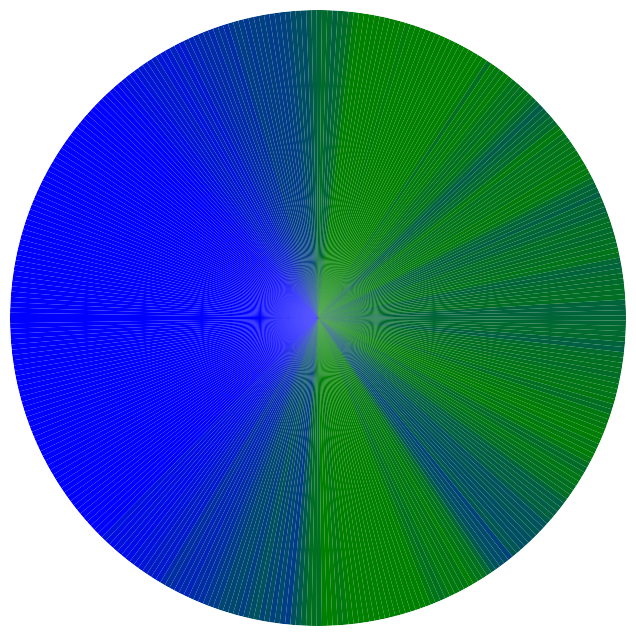

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# Probabilidades
# -----------------------------
p = euclidean_vector_complement

# -----------------------------
# Ángulos: 365 segmentos
# -----------------------------
n = 365
theta = np.linspace(0, 2*np.pi, n, endpoint=False)
width = 2*np.pi / n

# -----------------------------
# Colormap personalizado
# -----------------------------
cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "blue"),
        (0.15, "blue"),
        (0.70, "green"),
        (1.00, "green")
    ]
)

# Colores correspondientes a cada probabilidad
colors = cmap(p)

# -----------------------------
# Gráfica polar
# -----------------------------
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"projection": "polar"}
)

ax.bar(
    theta,
    np.ones(n),
    width=width,
    bottom=0.0,
    color=colors,
    edgecolor="none",
    align="edge"
)

# -----------------------------
# Orientación
# -----------------------------
ax.set_theta_zero_location("W")   # Día 1 arriba
ax.set_theta_direction(-1)        # sentido horario

# -----------------------------
# Apariencia
# -----------------------------
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xticks([])

ax.spines["polar"].set_visible(False)

plt.show()

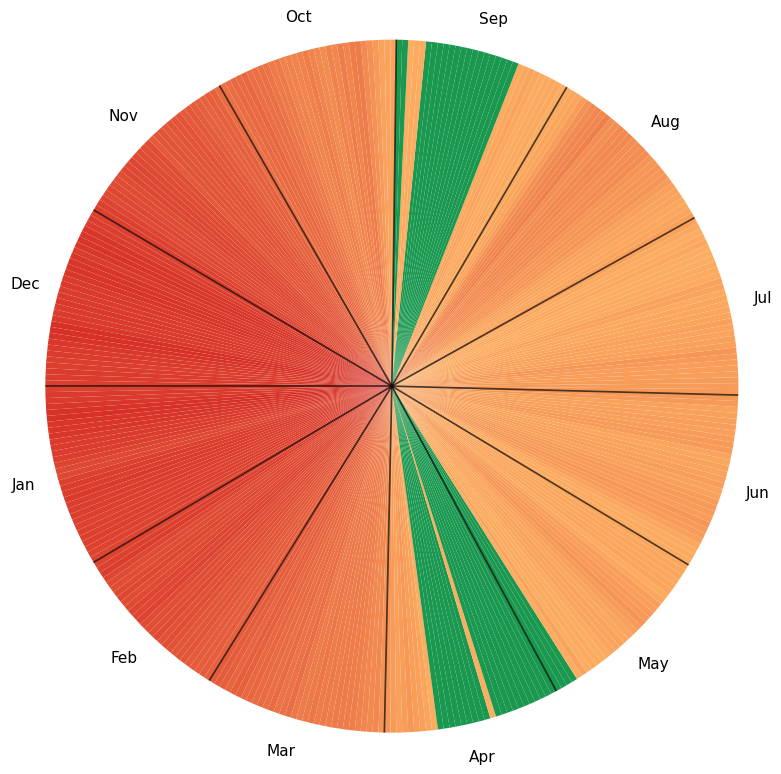

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ============================================================
# Probabilidades
# ============================================================

p = euclidean_vector_complement

n = 365

# ============================================================
# Ángulos
# ============================================================

theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
width = 2 * np.pi / n

# ============================================================
# Degradado rojo -> naranja -> verde
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "#d73027"),   # rojo
        (0.69, "#fdae61"),   # naranja
        (0.70, "#1a9850"),    # verde
        (1.00, "#1a9850")    # verde
    ]
)

colors = cmap(p)

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": "polar"}
)

# ============================================================
# Anillo de 365 días
# ============================================================

ax.bar(
    theta,
    np.ones(n),
    width=width,
    bottom=0.70,
    color=colors,
    edgecolor="none",
    align="edge"
)

# ============================================================
# Orientación
# ============================================================

ax.set_theta_zero_location("W")
ax.set_theta_direction(1)

# ============================================================
# Límites y apariencia
# ============================================================

ax.set_ylim(0.70, 1.00)

ax.set_yticks([])
ax.set_xticks([])

ax.spines["polar"].set_visible(False)

# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1,    # Jan
    32,   # Feb
    60,   # Mar
    91,   # Apr
    121,  # May
    152,  # Jun
    182,  # Jul
    213,  # Aug
    244,  # Sep
    274,  # Oct
    305,  # Nov
    335   # Dec
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

for day, month in zip(month_starts, month_names):

    angle = 2 * np.pi * (day-1) / 365

    # Línea divisoria
    ax.plot(
        [angle, angle],
        [0.70, 1.00],
        linewidth=1.2,
        color="black",
        alpha=0.7
    )

    # Nombre del mes
    ax.text(
        angle+0.26,
        1.03,
        month,
        ha="center",
        va="center",
        fontsize=11
    )

plt.show()

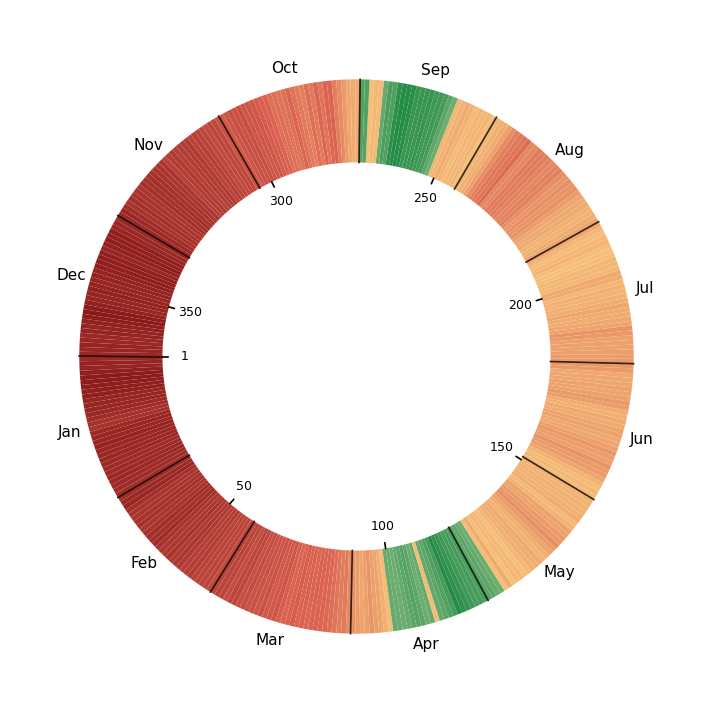

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ============================================================
# Probabilidades
# ============================================================

p = np.asarray(euclidean_vector_complement)

n = 365

# ============================================================
# Degradado rojo -> naranja -> verde
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "#8b1a1a"),   # rojo oscuro
        (0.40, "#d95f4f"),   # naranja rojizo
        (0.70, "#f6c27a"),   # mantener naranja
        (0.70, "#6fae72"),   # verde suave en el umbral
        (0.85, "#238b45"),   # verde
        (1.00, "#0f8a3b")    # verde oscuro
    ]
)

norm = Normalize(vmin=0, vmax=1)

colors = cmap(norm(p))

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# ============================================================
# Donut: 365 segmentos de igual tamaño
# ============================================================

ax.pie(
    np.ones(n),
    colors=colors,
    startangle=180,
    counterclock=True,
    wedgeprops={
        "width": 0.30,
        "edgecolor": "none"
    }
)

# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = list(np.arange(0, 351, 50))

for day in tick_days:

    angle = np.deg2rad(
        180 + (day) * 360 / 365
    )

    # Línea del tick
    ax.plot(
        [np.cos(angle) * 0.68, np.cos(angle) * 0.7],
        [np.sin(angle) * 0.68, np.sin(angle) * 0.7],
        color="black",
        linewidth=1.2
    )
    
    if day == 0:
        day=day+1

    # Etiqueta
    ax.text(
        np.cos(angle) * 0.62,
        np.sin(angle) * 0.62,
        str(day),
        ha="center",
        va="center",
        fontsize=9
    )

# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Ángulo de cada día
# 0° = derecha; 90° = arriba
def day_to_angle(day):
    return 180 + (day - 1) * 360 / 365


# ============================================================
# Líneas divisorias de los meses
# ============================================================

for day in month_starts:

    angle = np.deg2rad(day_to_angle(day))

    ax.plot(
        [np.cos(angle) * 0.70, np.cos(angle)],
        [np.sin(angle) * 0.70, np.sin(angle)],
        color="black",
        linewidth=1.2,
        alpha=0.8
    )


# ============================================================
# Etiquetas de los meses
# ============================================================

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]

for day, month in zip(month_midpoints, month_names):

    angle = np.deg2rad(day_to_angle(day))

    ax.text(
        np.cos(angle) * 1.07,
        np.sin(angle) * 1.07,
        month,
        ha="center",
        va="center",
        fontsize=11
    )


# ============================================================
# Apariencia
# ============================================================

ax.set_aspect("equal")
ax.axis("off")
plt.savefig(
    "Babaria_Euclidean.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)
plt.show()

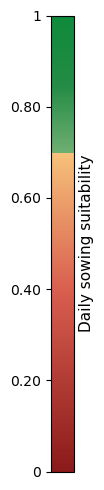

In [26]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ============================================================
# Colormap
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, "#8b1a1a"),
        (0.40, "#d95f4f"),
        (0.70, "#f6c27a"),
        (0.70, "#6fae72"),
        (0.85, "#238b45"),
        (1.00, "#0f8a3b")
    ]
)

norm = Normalize(vmin=0, vmax=1)

# ============================================================
# Figura exclusiva para la barra
# ============================================================

fig, ax = plt.subplots(figsize=(1.5, 5))

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.5,
    pad=0.05
)

cbar.set_label(
    "Daily sowing suitability",
    fontsize=11
)

cbar.set_ticks([0, 0.20, 0.40, 0.60, 0.80, 1.00])

cbar.ax.set_yticklabels([
    "0",
    "0.20",
    "0.40",
    "0.60",
    "0.80",
    "1"
])

cbar.ax.yaxis.set_ticks_position("left")

# Ocultar los ejes auxiliares
ax.remove()

plt.tight_layout()
plt.savefig(
    "Suitability.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)
plt.show()